In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.utils import resample

import pickle

sns.set(style="whitegrid")


In [2]:

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
display(df.head(5))

pd.set_option("display.max_columns", None)
display(df.head(2))

df.info()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:

df = df.drop(columns=["customerID"])
display(df.head(2))
print("Columns:", df.columns.tolist())


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:

print("Gender unique:", df["gender"].unique())
print("SeniorCitizen unique:", df["SeniorCitizen"].unique())

numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]
for col in df.columns:
    if col not in numerical_features_list:
        print(f"--- {col} ---")
        print(df[col].unique())
        print("-"*40)


Gender unique: ['Female' 'Male']
SeniorCitizen unique: [0 1]
--- gender ---
['Female' 'Male']
----------------------------------------
--- SeniorCitizen ---
[0 1]
----------------------------------------
--- Partner ---
['Yes' 'No']
----------------------------------------
--- Dependents ---
['No' 'Yes']
----------------------------------------
--- PhoneService ---
['No' 'Yes']
----------------------------------------
--- MultipleLines ---
['No phone service' 'No' 'Yes']
----------------------------------------
--- InternetService ---
['DSL' 'Fiber optic' 'No']
----------------------------------------
--- OnlineSecurity ---
['No' 'Yes' 'No internet service']
----------------------------------------
--- OnlineBackup ---
['Yes' 'No' 'No internet service']
----------------------------------------
--- DeviceProtection ---
['No' 'Yes' 'No internet service']
----------------------------------------
--- TechSupport ---
['No' 'Yes' 'No internet service']
---------------------------------------

In [5]:

print("Nulls per column:\n", df.isnull().sum())

mask_blank_total = df["TotalCharges"].astype(str).str.strip() == ""
print("Rows with blank TotalCharges:", mask_blank_total.sum())

df.loc[mask_blank_total, "TotalCharges"] = "0.0"
df["TotalCharges"] = df["TotalCharges"].astype(float)

df.info()
print(df["TotalCharges"].describe())


Nulls per column:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Rows with blank TotalCharges: 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   Multipl

In [6]:

print("Churn distribution:\n", df["Churn"].value_counts())


Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


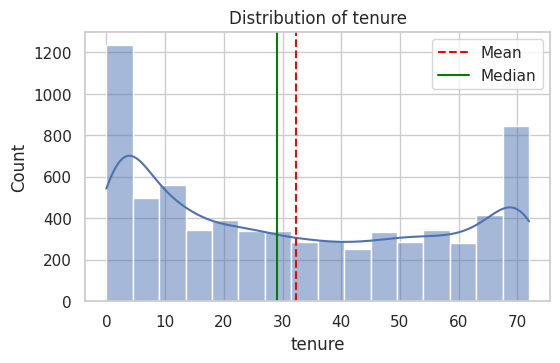

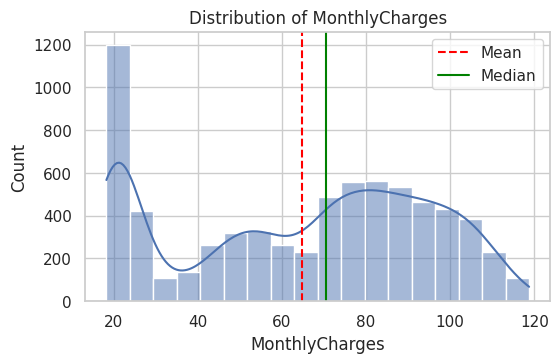

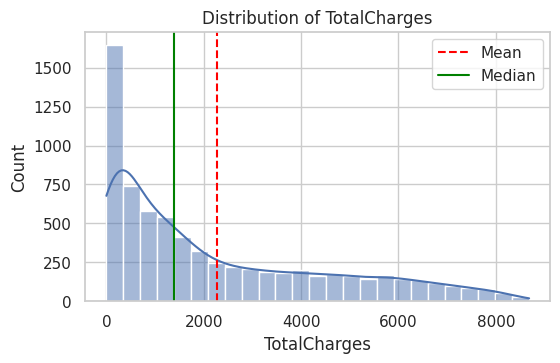

In [7]:

display(df.describe())

def plot_histogram(df, column_name):
    plt.figure(figsize=(6, 3.5))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="-", label="Median")
    plt.legend()
    plt.show()

plot_histogram(df, "tenure")
plot_histogram(df, "MonthlyCharges")
plot_histogram(df, "TotalCharges")


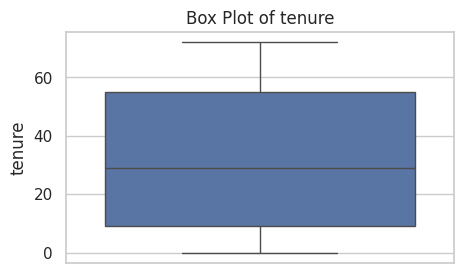

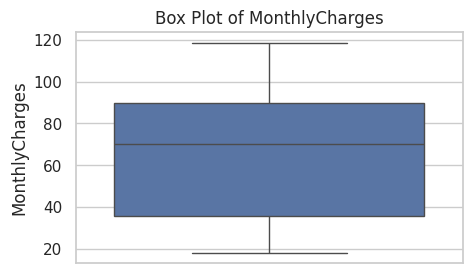

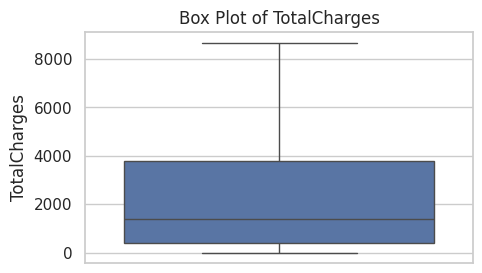

In [8]:

def plot_boxplot(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Box Plot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

plot_boxplot(df, "tenure")
plot_boxplot(df, "MonthlyCharges")
plot_boxplot(df, "TotalCharges")


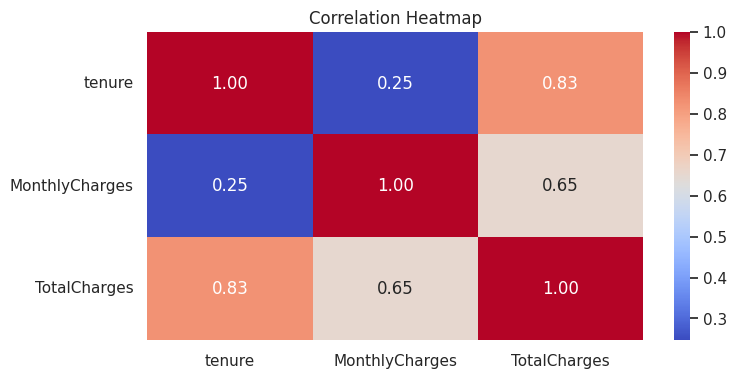

In [9]:

plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


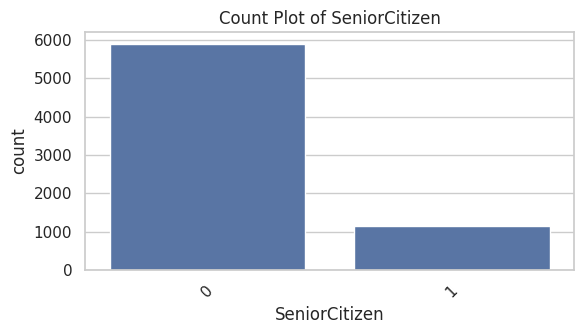

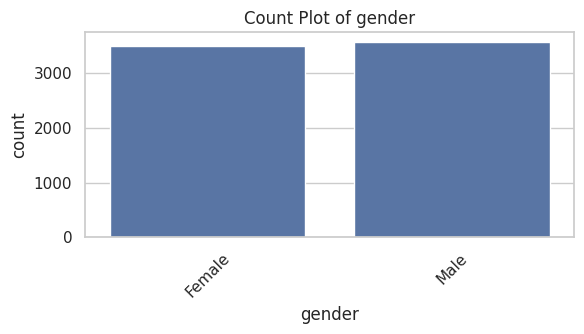

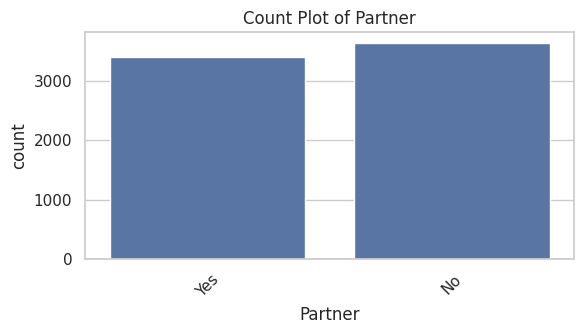

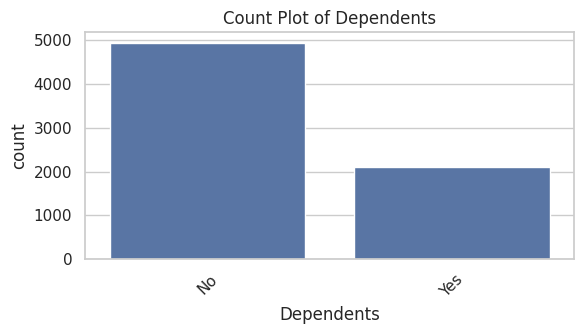

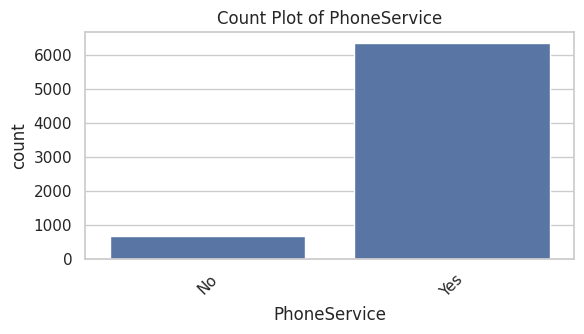

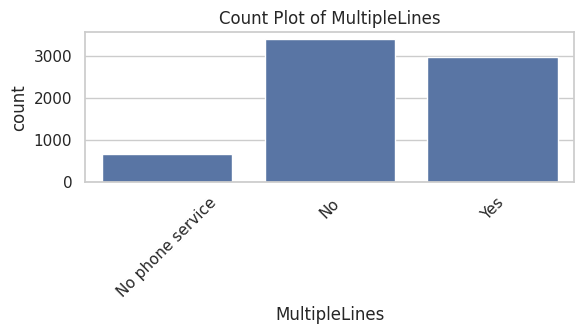

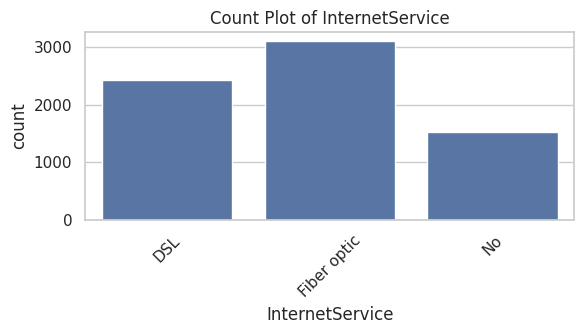

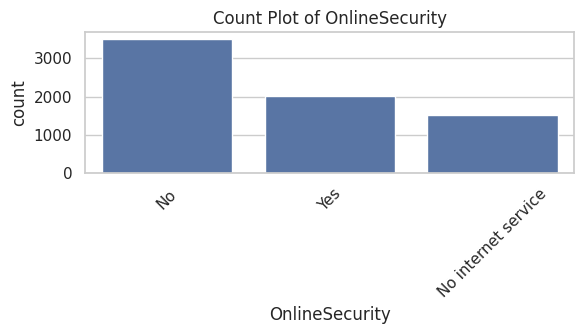

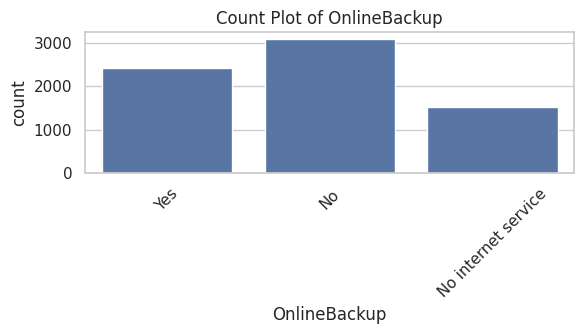

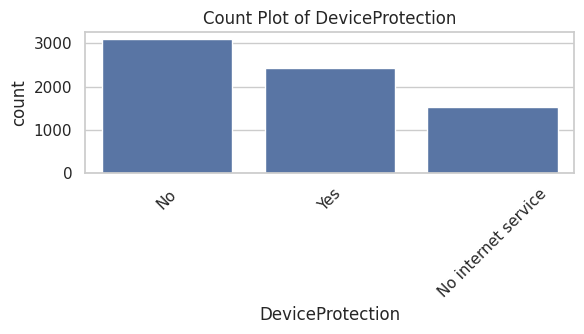

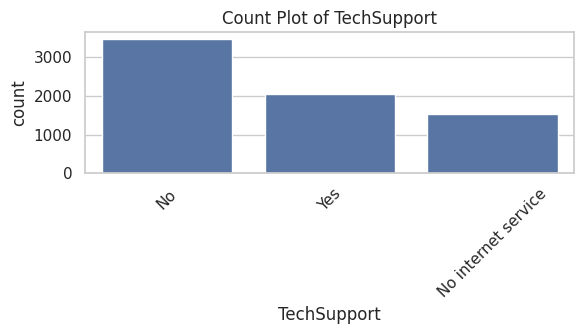

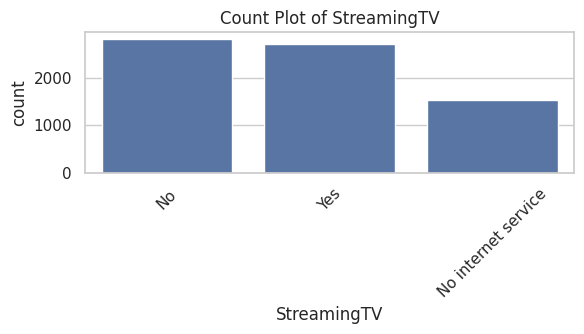

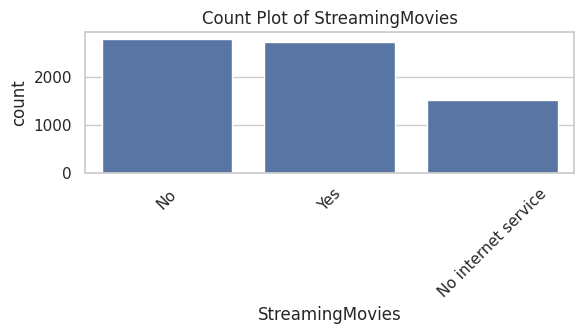

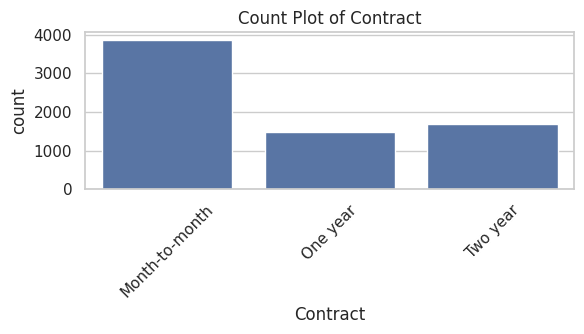

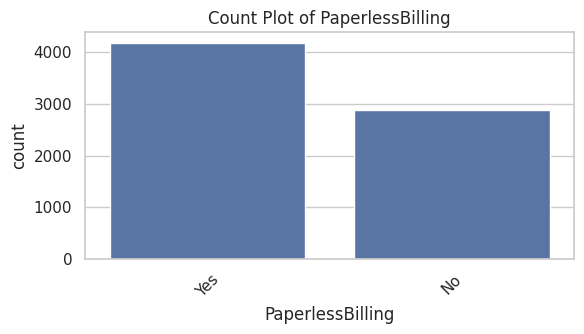

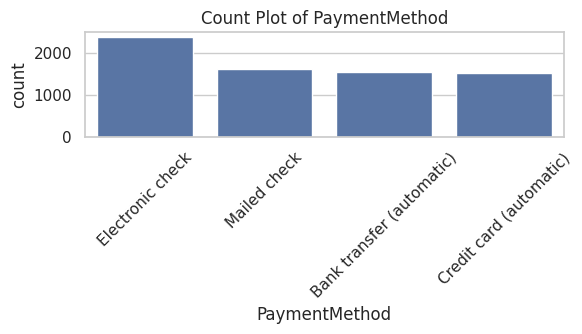

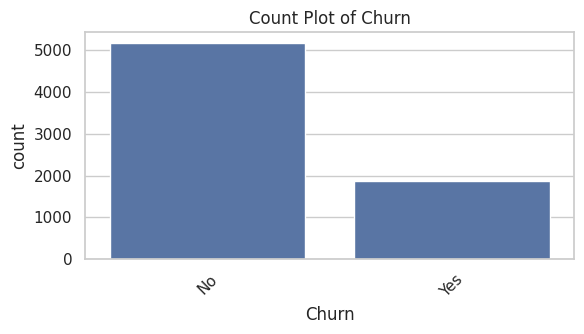

In [10]:

object_cols = df.select_dtypes(include="object").columns.to_list()
plot_cols = ["SeniorCitizen"] + object_cols

for col in plot_cols:
    plt.figure(figsize=(6, 3.5))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [11]:

df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})
print(df["Churn"].value_counts())
display(df.head(3))


Churn
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipython-input-3056432026.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [12]:

object_columns = df.select_dtypes(include="object").columns.tolist()
print("Object columns to encode:", object_columns)

encoders = {}
for column in object_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

display(df.head())
print("Saved encoders for columns:", list(encoders.keys()))


Object columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


Saved encoders for columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [13]:

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("y_train class counts:\n", y_train.value_counts())


Train shape: (5634, 19) Test shape: (1409, 19)
y_train class counts:
 Churn
0    4139
1    1495
Name: count, dtype: int64


In [14]:

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE - train shape:", X_train_smote.shape)
print("After SMOTE - class counts:\n", y_train_smote.value_counts())


After SMOTE - train shape: (8278, 19)
After SMOTE - class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64


In [15]:

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")
}

cv_scores = {}
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_scores[model_name] = scores
    print(f"{model_name} CV Accuracy: {np.mean(scores):.4f}")
    print("-"*60)


Training Decision Tree with default parameters
Decision Tree CV Accuracy: 0.7875
------------------------------------------------------------
Training Random Forest with default parameters
Random Forest CV Accuracy: 0.8383
------------------------------------------------------------
Training XGBoost with default parameters


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:33:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:33:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:33:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:33:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost CV Accuracy: 0.8315
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:33:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote, y_train_smote)

y_test_pred = rfc.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Accuracy: 0.7792760823278921
Confusion Matrix:
 [[880 155]
 [156 218]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.58      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [17]:

model_data = {"model": rfc, "features_names": X.columns.tolist()}
with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved to customer_churn_model.pkl")


Model saved to customer_churn_model.pkl


In [18]:

with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]
print("Loaded model:", loaded_model)
print("Feature names:", feature_names)


Loaded model: RandomForestClassifier(random_state=42)
Feature names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [19]:

input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

for column, encoder in encoders.items():
    if column in input_data_df.columns:
        val = input_data_df.at[0, column]
        if val not in encoder.classes_:
            raise ValueError(f"Value {val} unseen in training for column {column}")
        input_data_df[column] = encoder.transform(input_data_df[column])

input_data_df = input_data_df[feature_names]
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print("Prediction:", "Churn" if prediction[0] == 1 else "No Churn")
print("Prediction probabilities:", pred_prob)


Prediction: No Churn
Prediction probabilities: [[0.76 0.24]]


In [20]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
scores = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=skf, scoring="accuracy")
print("Stratified K-Fold CV Scores:", scores)
print("Mean Accuracy:", np.mean(scores))


Stratified K-Fold CV Scores: [0.8442029  0.8423913  0.84963768 0.84954683 0.85800604]
Mean Accuracy: 0.8487569508297211


In [21]:

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "bootstrap": [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy"
)

rf_random_search.fit(X_train_smote, y_train_smote)
print("Best Params RF:", rf_random_search.best_params_)
print("Best Score RF:", rf_random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params RF: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}
Best Score RF: 0.852139396062291


In [22]:

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"),
    param_distributions=xgb_param_grid,
    n_iter=10,
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy"
)

xgb_random_search.fit(X_train_smote, y_train_smote)
print("Best Params XGB:", xgb_random_search.best_params_)
print("Best Score XGB:", xgb_random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:35:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params XGB: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best Score XGB: 0.8514156340762147


In [23]:

train_df = pd.concat([X_train, y_train], axis=1)
majority = train_df[train_df.Churn == 0]
minority = train_df[train_df.Churn == 1]

majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

downsampled_df = pd.concat([majority_downsampled, minority])
downsampled_df = downsampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_down = downsampled_df.drop("Churn", axis=1)
y_train_down = downsampled_df["Churn"]
print("After Downsampling counts:\n", y_train_down.value_counts())


After Downsampling counts:
 Churn
0    1495
1    1495
Name: count, dtype: int64


In [24]:

rf_down = RandomForestClassifier(random_state=42)
rf_down.fit(X_train_down, y_train_down)
y_test_pred_down = rf_down.predict(X_test)
print("Accuracy (Downsampled):", accuracy_score(y_test, y_test_pred_down))
print("Confusion:\n", confusion_matrix(y_test, y_test_pred_down))
print("Report:\n", classification_report(y_test, y_test_pred_down))


Accuracy (Downsampled): 0.7473385379701917
Confusion:
 [[768 267]
 [ 89 285]]
Report:
               precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



,Model,Accuracy,Precision,Recall,F1-Score
0,RF Original,0.794890,0.643098,0.510695,0.569300
1,RF SMOTE,0.779276,0.584450,0.582888,0.583668
2,RF Downsampled,0.747339,0.516304,0.762032,0.615551


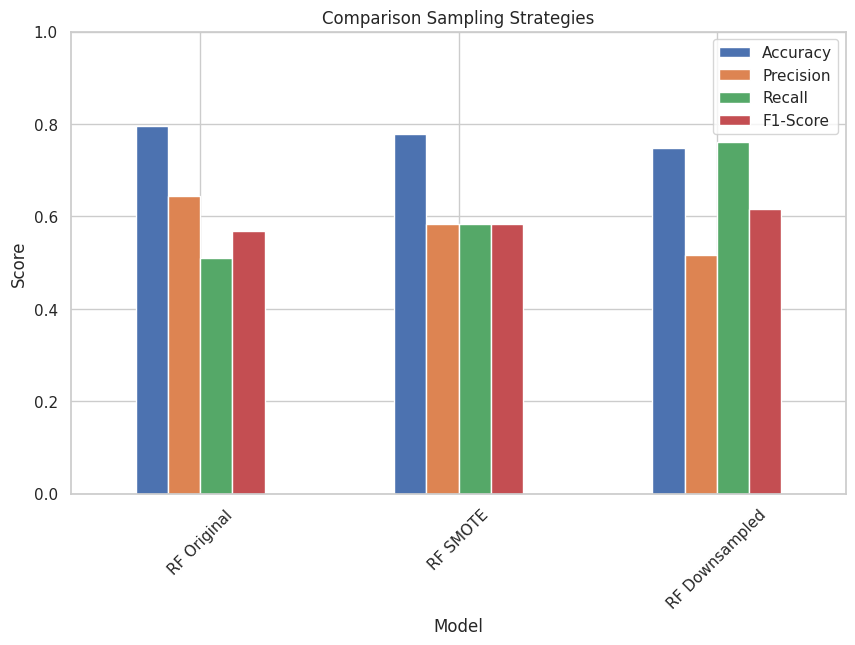

In [25]:

def evaluate_model(model, X_test, y_test, label):
    y_pred = model.predict(X_test)
    return {
        "Model": label,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

rf_orig = RandomForestClassifier(random_state=42)
rf_orig.fit(X_train, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

results = []
results.append(evaluate_model(rf_orig, X_test, y_test, "RF Original"))
results.append(evaluate_model(rf_smote, X_test, y_test, "RF SMOTE"))
results.append(evaluate_model(rf_down, X_test, y_test, "RF Downsampled"))

results_df = pd.DataFrame(results)
display(results_df)

results_df.set_index("Model")[["Accuracy","Precision","Recall","F1-Score"]].plot(
    kind="bar", figsize=(10,6), rot=45
)
plt.title("Comparison Sampling Strategies")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()


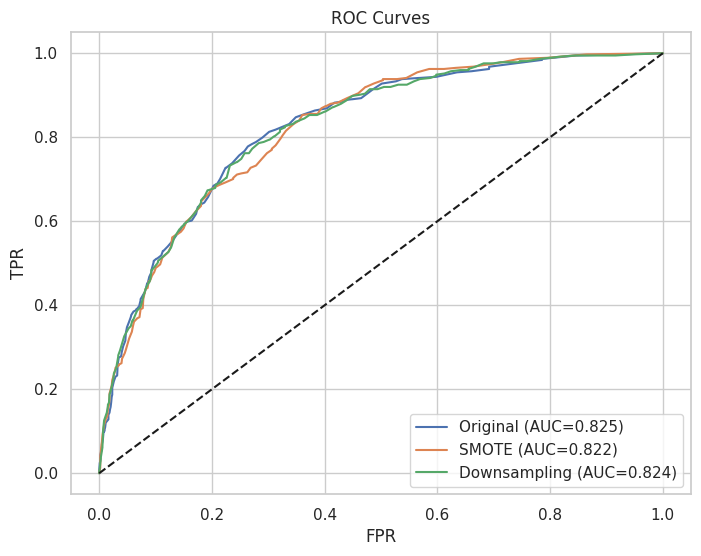

In [26]:

plt.figure(figsize=(8,6))

y_prob_orig = rf_orig.predict_proba(X_test)[:,1]
fpr_orig, tpr_orig, _ = roc_curve(y_test, y_prob_orig)
roc_auc_orig = auc(fpr_orig, tpr_orig)
plt.plot(fpr_orig, tpr_orig, label=f"Original (AUC={roc_auc_orig:.3f})")

y_prob_smote = rf_smote.predict_proba(X_test)[:,1]
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)
plt.plot(fpr_smote, tpr_smote, label=f"SMOTE (AUC={roc_auc_smote:.3f})")

y_prob_down = rf_down.predict_proba(X_test)[:,1]
fpr_down, tpr_down, _ = roc_curve(y_test, y_prob_down)
roc_auc_down = auc(fpr_down, tpr_down)
plt.plot(fpr_down, tpr_down, label=f"Downsampling (AUC={roc_auc_down:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


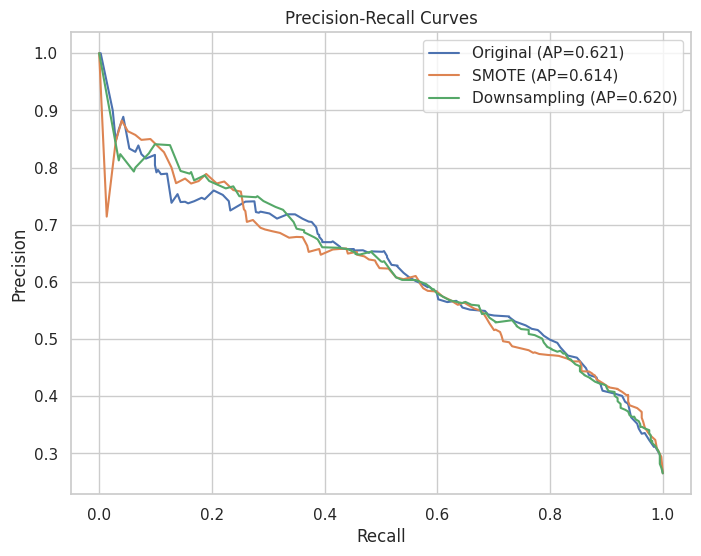

In [27]:

plt.figure(figsize=(8,6))

prec_orig, rec_orig, _ = precision_recall_curve(y_test, y_prob_orig)
ap_orig = average_precision_score(y_test, y_prob_orig)
plt.plot(rec_orig, prec_orig, label=f"Original (AP={ap_orig:.3f})")

prec_smote, rec_smote, _ = precision_recall_curve(y_test, y_prob_smote)
ap_smote = average_precision_score(y_test, y_prob_smote)
plt.plot(rec_smote, prec_smote, label=f"SMOTE (AP={ap_smote:.3f})")

prec_down, rec_down, _ = precision_recall_curve(y_test, y_prob_down)
ap_down = average_precision_score(y_test, y_prob_down)
plt.plot(rec_down, prec_down, label=f"Downsampling (AP={ap_down:.3f})")

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()
